# Experiment 03 - 48h run detail (8 probes x 10 sites)

`run_20260612_48h` (2026-06-14 19:25 -> 2026-06-16 19:16 PKT, two days). One idea per
graph, all times PKT, **mean** used for averages. Heatmaps read at a glance (green
good / red bad, or one colour per city). Companion to
`findings/03_longitudinal_routing_48h.md`.

In [29]:
import glob, os, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates, matplotlib.patches as mpatches

RESULTS = '../experiments/03_longitudinal_routing/results/run_20260612_48h'
ts_file = sorted(glob.glob(os.path.join(RESULTS, 'trace_summary_2026*.csv')))[-1]
pg_file = sorted(glob.glob(os.path.join(RESULTS, 'ping_series_2026*.csv')))[-1]

def to_pkt(col):  # UTC string -> naive PKT (UTC+5) so axes label in local time
    return pd.to_datetime(col).dt.tz_convert('Asia/Karachi').dt.tz_localize(None)

df = pd.read_csv(ts_file)
df['t'] = to_pkt(df['trace_time']); df['hr'] = df['t'].dt.floor('h'); df['hour'] = df['t'].dt.hour
ok = df[df['destination_responded']]
pg = pd.read_csv(pg_file); pg['t'] = to_pkt(pg['ping_time'])
PROBES = sorted(df['probe_city'].unique())

def time_heatmap(matrix, title, cmap, vmin, vmax):
    cols = list(matrix.columns); x0, x1 = mdates.date2num(cols[0]), mdates.date2num(cols[-1])
    fig, ax = plt.subplots(figsize=(14, 0.45 * len(matrix.index) + 1.6))
    im = ax.imshow(matrix.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[x0, x1, len(matrix.index), 0], interpolation='nearest')
    ax.set_yticks([i + 0.5 for i in range(len(matrix.index))]); ax.set_yticklabels(matrix.index, fontsize=8)
    ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M')); ax.tick_params(axis='x', labelsize=8)
    ax.set_title(title, fontsize=11)
    return fig, ax, im

# city coordinates (for the theoretical-latency graph)
CITY_COORD = {
    'Islamabad': (33.69, 73.06), 'Lahore': (31.55, 74.34), 'Karachi': (24.86, 67.01),
    'Haripur': (33.99, 72.93), 'LUMS': (31.47, 74.41),
    'Singapore': (1.35, 103.82), 'Secaucus': (40.79, -74.06), 'New Jersey': (40.79, -74.06),
    'New York': (40.71, -74.01), 'Brooklyn': (40.65, -73.95), 'Tempe': (33.43, -111.94),
    'Cologne': (50.94, 6.96), 'Frankfurt': (50.11, 8.68), 'London': (51.51, -0.13),
    'Marseille': (43.30, 5.37), 'Gebze': (40.80, 29.44), 'Istanbul': (41.01, 28.98),
    'Muscat': (23.59, 58.41),
}
def coord_of(loc):
    if not isinstance(loc, str): return None
    for name, c in CITY_COORD.items():
        if name in loc: return c
    return None
def haversine_km(a, b):
    R = 6371.0; la1, lo1, la2, lo2 = map(math.radians, [a[0], a[1], b[0], b[1]])
    h = math.sin((la2-la1)/2)**2 + math.cos(la1)*math.cos(la2)*math.sin((lo2-lo1)/2)**2
    return 2*R*math.asin(math.sqrt(h))
FIBER_KMS = 200000.0           # light in fibre ~ 2/3 c
def theo_rtt_ms(km): return 2.0 * km / FIBER_KMS * 1000.0

print('trace rounds:', len(df), '| probes:', len(PROBES), '| sites:', df['target_label'].nunique())
print('span PKT:', df['t'].min(), '->', df['t'].max())

trace rounds: 14319 | probes: 8 | sites: 10
span PKT: 2026-06-14 19:25:33 -> 2026-06-16 19:16:46


## 1. Which sites reply at all?

Red = 0%: those firewall ICMP at the host (the traceroute still reaches their network),
so they are blocked, not down.

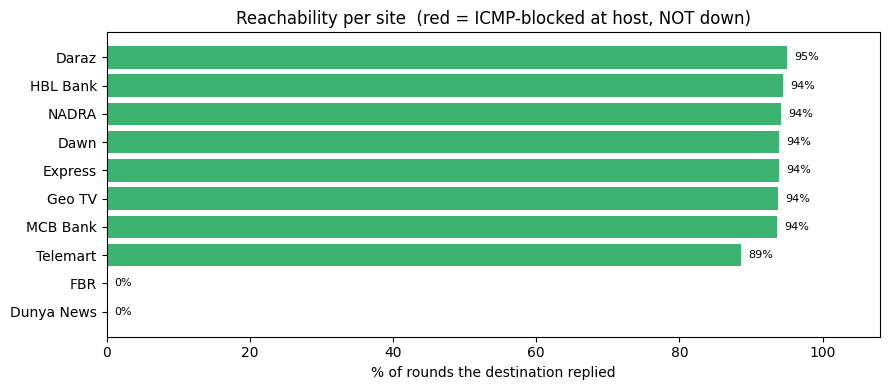

In [30]:
reach = (df.groupby('target_label')['destination_responded'].mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(reach.index, reach.values, color=['tomato' if v == 0 else 'mediumseagreen' for v in reach.values])
for i, v in enumerate(reach.values): ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=8)
ax.set_xlim(0, 108); ax.set_xlabel('% of rounds the destination replied')
ax.set_title('Reachability per site  (red = ICMP-blocked at host, NOT down)')
plt.tight_layout(); plt.show()

## 2. Outage: which probe went dark, and when

Green = up that hour, red = produced nothing (ISP down). One red band = the whole
story. Exact window printed below.

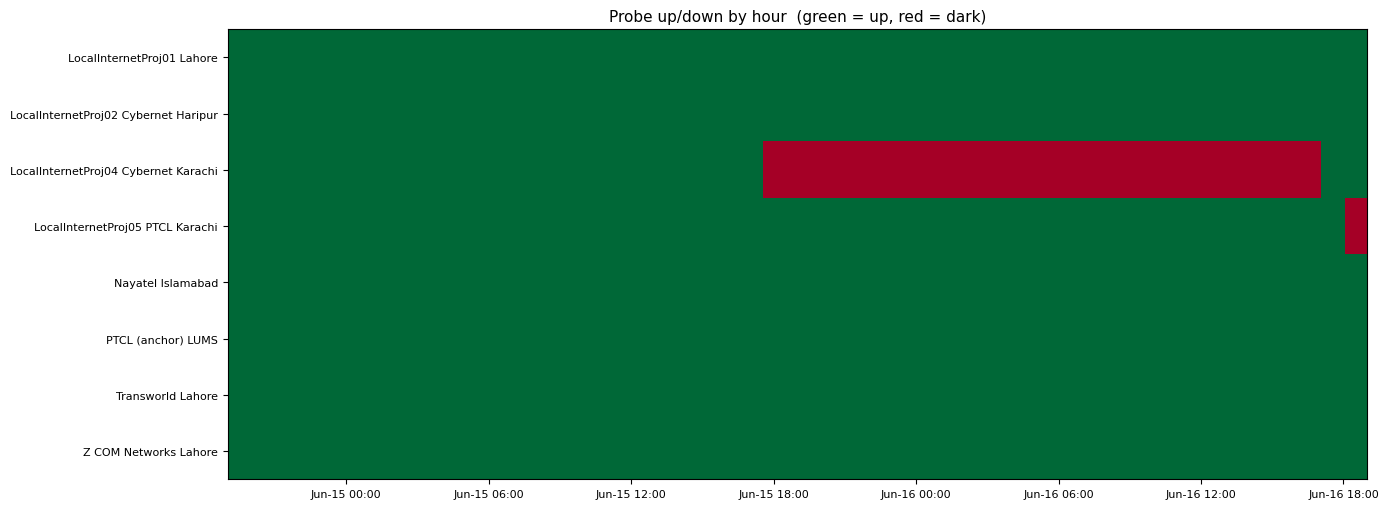

Outage windows (gap > 25 min):
  LocalInternetProj04 Cybernet Karachi DOWN Jun-15 17:26 -> UP Jun-16 18:58 PKT  (25.5 h)


In [31]:
ct = df.groupby(['probe_city', 'hr']).size().unstack('hr').reindex(index=PROBES)
live = (ct.fillna(0) > 0).astype(int)
fig, ax, im = time_heatmap(live, 'Probe up/down by hour  (green = up, red = dark)', 'RdYlGn', 0, 1)
plt.tight_layout(); plt.show()

print('Outage windows (gap > 25 min):')
found = False
for probe, g in df.groupby('probe_city'):
    tps = g['t'].sort_values().drop_duplicates().reset_index(drop=True)
    for i in range(1, len(tps)):
        d = (tps[i] - tps[i-1]).total_seconds() / 60
        if d > 25:
            found = True
            print(f'  {probe:<34} DOWN {tps[i-1]:%b-%d %H:%M} -> UP {tps[i]:%b-%d %H:%M} PKT  ({d/60:.1f} h)')
if not found: print('  none')

## 3. Which sites were reachable, by hour

A row red the whole time = ICMP-blocked (Dunya, FBR). A row that turns red only for a
stretch would be a real site outage (there were none).

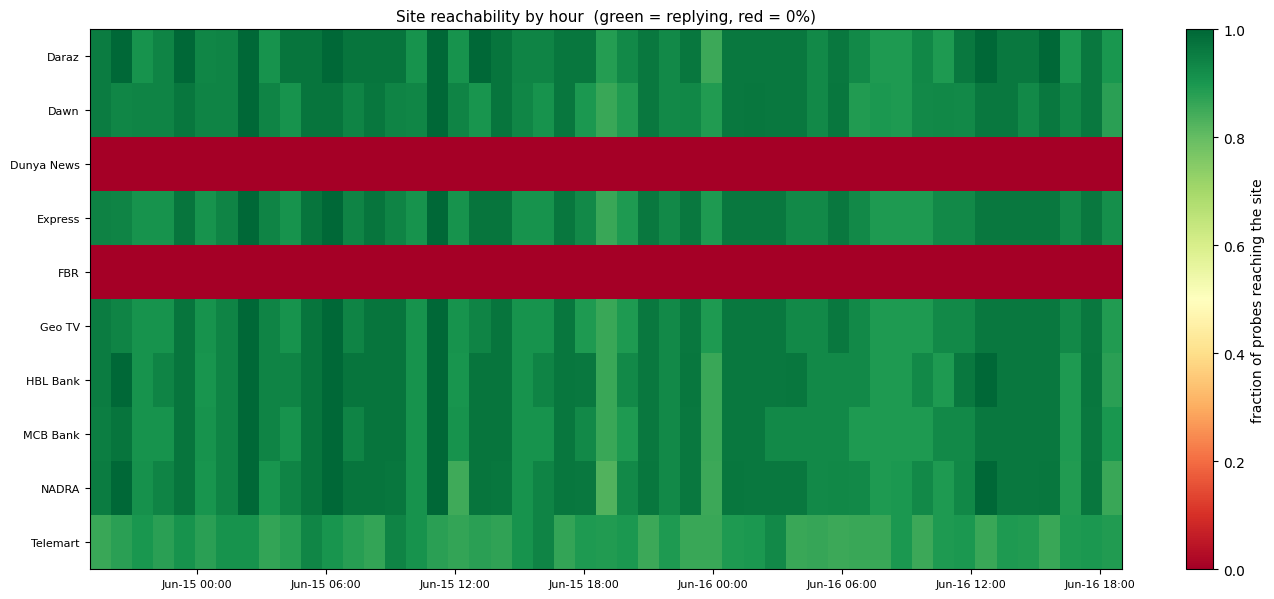

In [32]:
rr = df.groupby(['hr', 'target_label'])['destination_responded'].mean().unstack('target_label').T
fig, ax, im = time_heatmap(rr, 'Site reachability by hour  (green = replying, red = 0%)', 'RdYlGn', 0, 1)
plt.colorbar(im, ax=ax, label='fraction of probes reaching the site'); plt.tight_layout(); plt.show()

## 4. Mean latency by site and ISP

Darker = slower. The Cloudflare rows (Dawn, Express, Geo, Telemart) show the gap: a
few ms on Nayatel/Cybernet, 100-280 ms from the PTCL probes, for the same content.

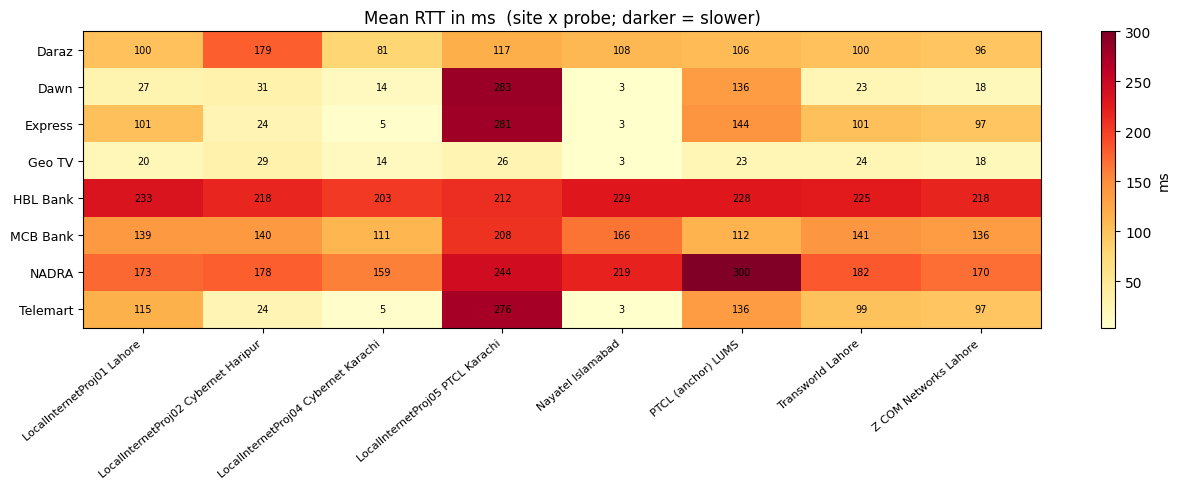

In [33]:
piv = ok.pivot_table(index='target_label', columns='probe_city', values='dest_rtt_ms', aggfunc='mean').reindex(columns=PROBES)
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(piv.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index, fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if pd.notna(v): ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7)
ax.set_title('Mean RTT in ms  (site x probe; darker = slower)')
plt.colorbar(im, ax=ax, label='ms'); plt.tight_layout(); plt.show()

## 5. CDN serving-city flips (one graph per site)

Rows are probes, x is time, **each colour is a city** the CDN served from. A row that
changes colour = the serving edge flipped. NADRA (Akamai) and MCB (Sucuri) move a lot.
A **grey** row means the probe reached the destination but there was no geolocatable
handoff hop to place on a map - i.e. it **peers directly** with the CDN (e.g. Transworld
straight into Akamai/Sucuri), which is itself a sign of efficient routing.

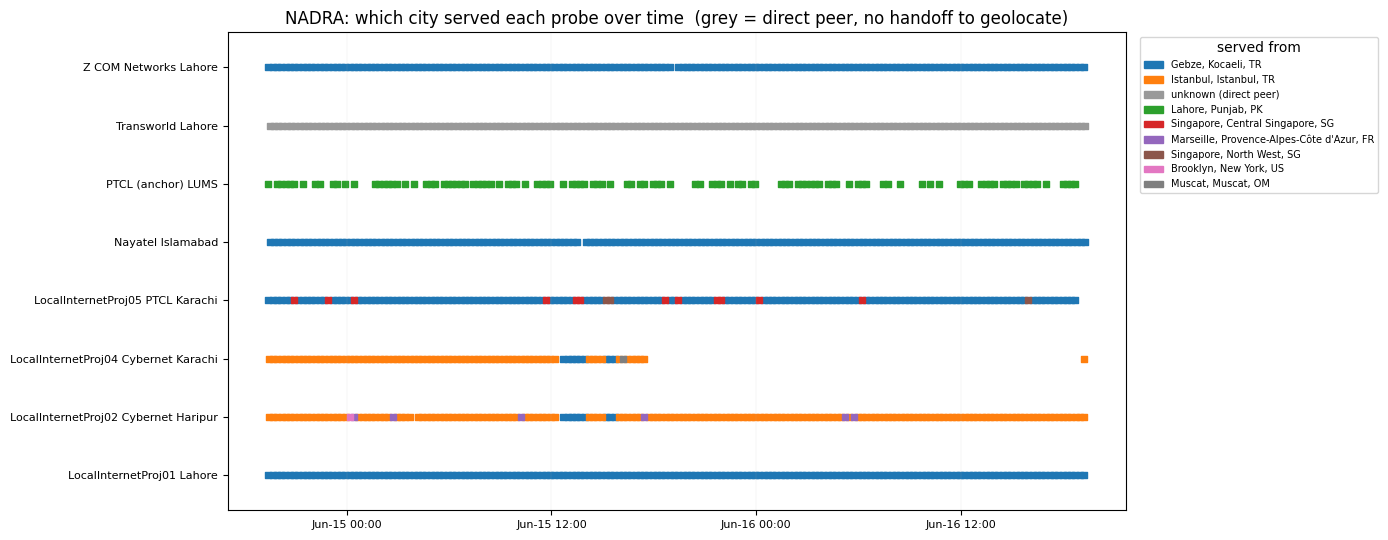

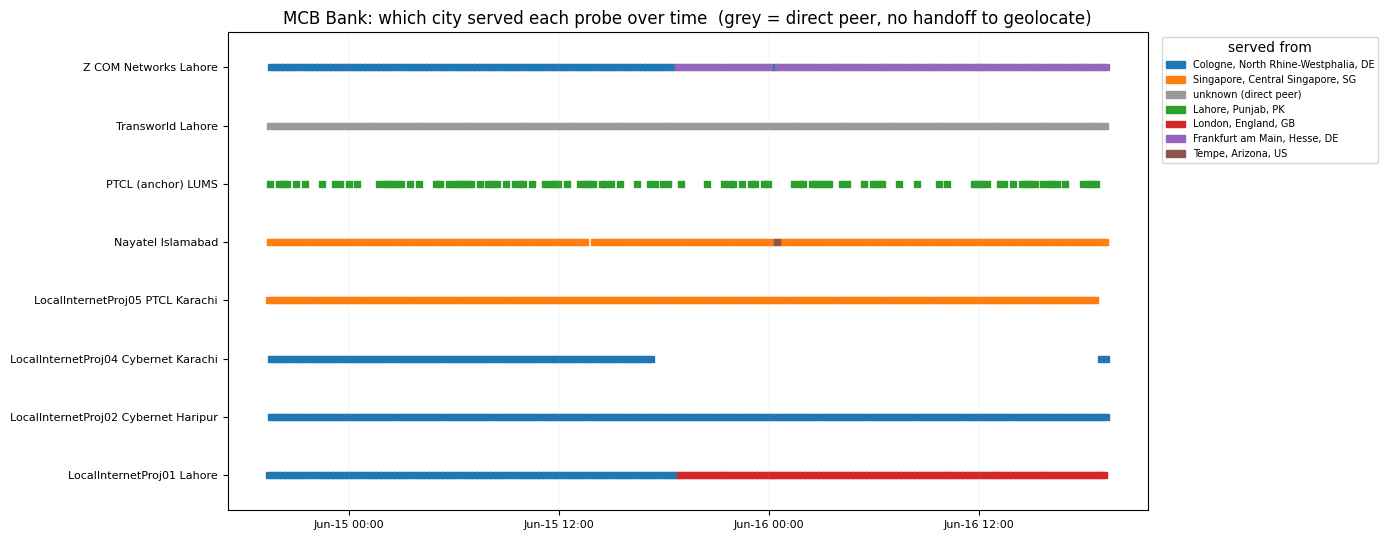

In [40]:
def metro_timeline(site):
    g = ok[ok['target_label'] == site].copy()
    # rounds that reached the dest but have no geolocatable handoff hop = direct peering
    g['loc'] = g['dest_location'].fillna('unknown (direct peer)')
    metros = g['loc'].value_counts().index.tolist()
    real = [m for m in metros if m != 'unknown (direct peer)']
    cmap = plt.get_cmap('tab10'); cidx = {m: i for i, m in enumerate(real)}; yidx = {p: i for i, p in enumerate(PROBES)}
    def colour(m):
        return '0.6' if m == 'unknown (direct peer)' else cmap(cidx[m] % 10)
    fig, ax = plt.subplots(figsize=(14, 0.5 * len(PROBES) + 1.5))
    for m in metros:
        s = g[g['loc'] == m]
        ax.scatter(s['t'], s['probe_city'].map(yidx), marker='s', s=16, color=colour(m))
    ax.set_yticks(range(len(PROBES))); ax.set_yticklabels(PROBES, fontsize=8); ax.set_ylim(-0.6, len(PROBES) - 0.4)
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 12)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d %H:%M')); ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, axis='x', lw=0.3, alpha=0.3)
    handles = [mpatches.Patch(color=colour(m), label=m) for m in metros]
    ax.legend(handles=handles, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', title='served from')
    ax.set_title(f'{site}: which city served each probe over time  (grey = direct peer, no handoff to geolocate)')
    plt.tight_layout(); plt.show()

metro_timeline('NADRA')
metro_timeline('MCB Bank')

## 6. Diurnal: does latency rise in the evening?

Mean RTT by hour of day (PKT), holding one clean probe (Nayatel) fixed. Flat lines
across the shaded evening = **no congestion cycle**; the offshore cost is structural.

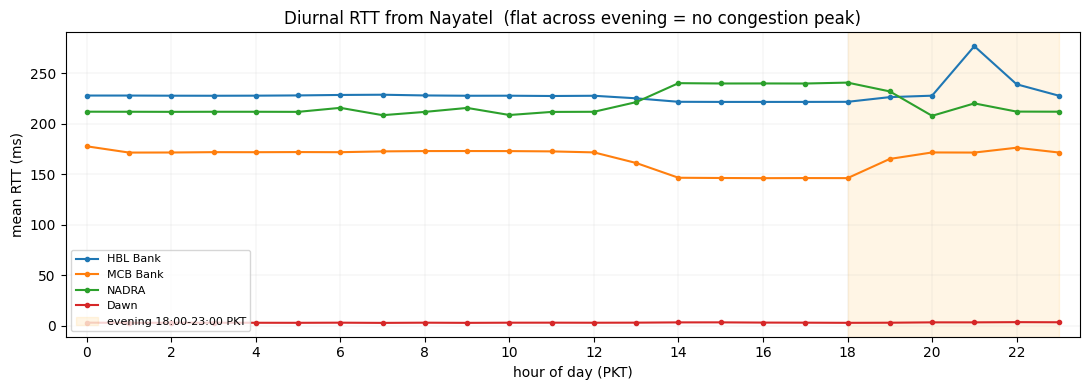

In [41]:
nay = ok[ok['probe_city'].str.startswith('Nayatel')]
fig, ax = plt.subplots(figsize=(11, 4))
for s in ['HBL Bank', 'MCB Bank', 'NADRA', 'Dawn']:
    h = nay[nay['target_label'] == s].groupby('hour')['dest_rtt_ms'].mean()
    ax.plot(h.index, h.values, marker='o', ms=3, label=s)
ax.axvspan(18, 23, color='orange', alpha=0.10, label='evening 18:00-23:00 PKT')
ax.set_xticks(range(0, 24, 2)); ax.set_xlim(-0.5, 23.5)
ax.set_xlabel('hour of day (PKT)'); ax.set_ylabel('mean RTT (ms)')
ax.set_title('Diurnal RTT from Nayatel  (flat across evening = no congestion peak)')
ax.legend(fontsize=8); ax.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

## 7. Theoretical vs actual latency (the inflation cost)

For each (probe, site) we compute the **theoretical** RTT - the absolute physical floor
set by the fibre distance and the speed of light in fibre (about 2/3 c) - and plot it
against the **measured mean** RTT. Points on the dashed line are at the physical limit;
the **gap above the line is the real-world overhead** (routing detours, queueing,
processing). Points clustered near `theoretical = 0` are CDN edges served from the
probe's own city (a few ms of intra-city routing, no real distance). The table lists
the most inflated paths, and separately the near-floor local edges.

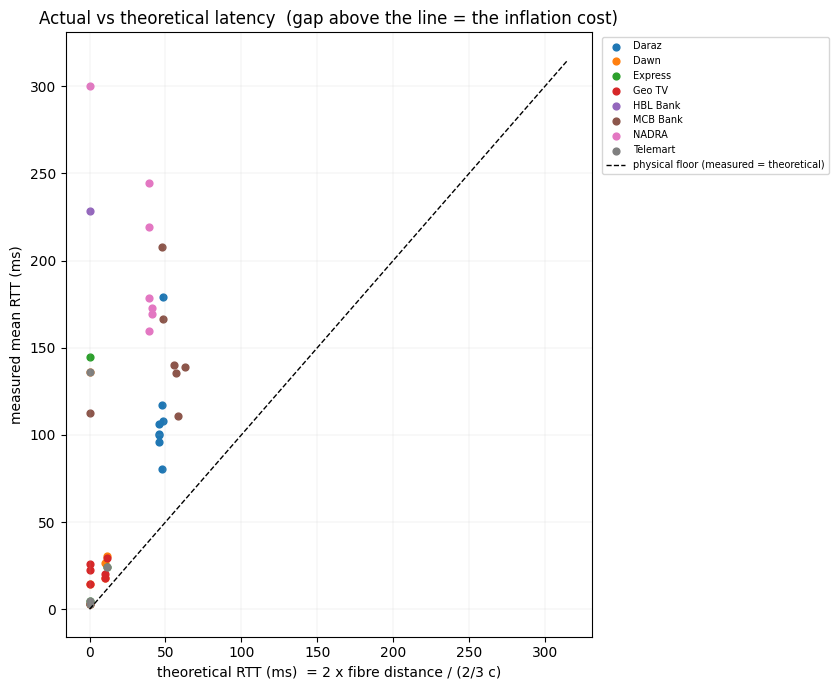

Biggest overhead above the physical floor (measured - theoretical):
(few-ms overhead = near-optimal; a nearby served_from city with huge overhead = a geo-mislabelled detour, e.g. PTCL)


,site,probe,served_from,km,theoretical_ms,measured_ms,overhead_ms
0,NADRA,PTCL (anchor) LUMS,Lahore,11,0.1,300.1,300.0
1,HBL Bank,PTCL (anchor) LUMS,Lahore,11,0.1,228.4,228.3
2,NADRA,LocalInternetProj05 PTCL Karachi,Gebze,3892,38.9,244.3,205.4
3,NADRA,Nayatel Islamabad,Gebze,3900,39.0,219.1,180.1
4,MCB Bank,LocalInternetProj05 PTCL Karachi,Singapore,4736,47.4,208.0,160.6
5,Express,PTCL (anchor) LUMS,Lahore,11,0.1,144.4,144.3
6,NADRA,LocalInternetProj02 Cybernet Haripur,Istanbul,3913,39.1,178.3,139.2
7,Telemart,PTCL (anchor) LUMS,Lahore,11,0.1,136.2,136.1
8,Dawn,PTCL (anchor) LUMS,Lahore,11,0.1,135.8,135.7
9,NADRA,LocalInternetProj01 Lahore,Gebze,4112,41.1,173.0,131.9


In [42]:
rows = []
for (site, probe), g in ok.groupby(['target_label', 'probe_city']):
    mode = g['dest_location'].mode()
    loc = mode.iloc[0] if len(mode) else None
    pc, dc = coord_of(probe), coord_of(loc)
    if pc and dc:
        km = haversine_km(pc, dc)
        rows.append({'site': site, 'probe': probe, 'served_from': (loc.split(',')[0] if loc else loc),
                     'km': round(km), 'theoretical_ms': round(theo_rtt_ms(km), 1),
                     'measured_ms': round(g['dest_rtt_ms'].mean(), 1)})
T = pd.DataFrame(rows)
T['overhead_ms'] = (T['measured_ms'] - T['theoretical_ms']).round(1)   # how far above the floor

fig, ax = plt.subplots(figsize=(8.5, 7))
for site, s in T.groupby('site'):
    ax.scatter(s['theoretical_ms'], s['measured_ms'], s=24, label=site)
lim = max(T['theoretical_ms'].max(), T['measured_ms'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='physical floor (measured = theoretical)')
ax.set_xlabel('theoretical RTT (ms)  = 2 x fibre distance / (2/3 c)')
ax.set_ylabel('measured mean RTT (ms)')
ax.set_title('Actual vs theoretical latency  (gap above the line = the inflation cost)')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left'); ax.grid(True, lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()

print('Biggest overhead above the physical floor (measured - theoretical):')
print('(few-ms overhead = near-optimal; a nearby served_from city with huge overhead = a geo-mislabelled detour, e.g. PTCL)')
display(T.sort_values('overhead_ms', ascending=False).head(12).reset_index(drop=True))

## 8. Same site, same ISP, two different cities

We have the **same ISP in two cities**: Cybernet in Haripur and Karachi (both AS9541),
and PTCL in Lahore/LUMS and Karachi (both AS17557). Comparing them to the same site
isolates the effect of the **probe's city** (distance from the content) from the ISP.

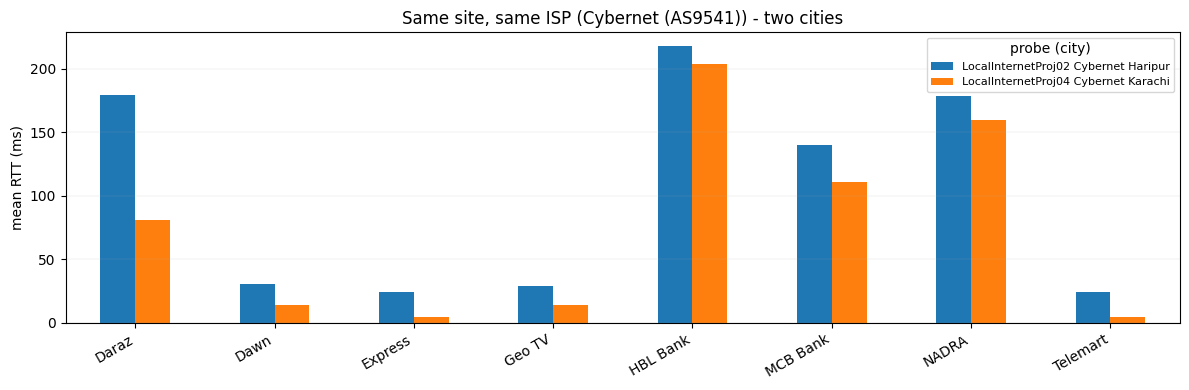

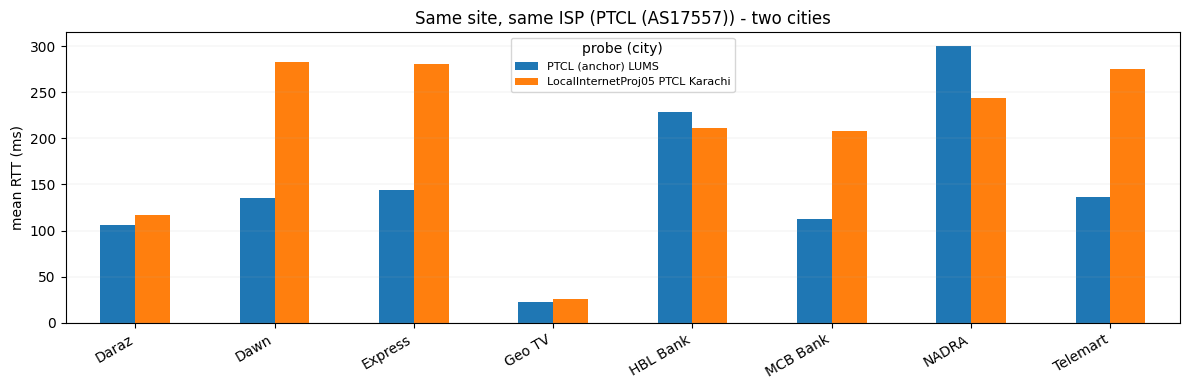

In [43]:
pairs = {
    'Cybernet (AS9541)': ['LocalInternetProj02 Cybernet Haripur', 'LocalInternetProj04 Cybernet Karachi'],
    'PTCL (AS17557)':    ['PTCL (anchor) LUMS',                    'LocalInternetProj05 PTCL Karachi'],
}
for isp, (pa, pb) in pairs.items():
    m = (ok[ok['probe_city'].isin([pa, pb])]
         .groupby(['target_label', 'probe_city'])['dest_rtt_ms'].mean().unstack('probe_city')
         .reindex(columns=[pa, pb]).dropna(how='all'))
    ax = m.plot(kind='bar', figsize=(12, 4))
    ax.set_ylabel('mean RTT (ms)'); ax.set_xlabel('')
    ax.set_title(f'Same site, same ISP ({isp}) - two cities')
    ax.legend(fontsize=8, title='probe (city)'); ax.grid(True, axis='y', lw=0.3, alpha=0.4)
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 9. RTT distribution and jitter, same destination across probes

For one destination (HBL Bank, reachable from every probe), the **jitter** (std dev of
RTT) per probe, then the **probability distribution** of RTT per probe (one panel
each). Uses the 1/5-min ping series for more samples. A tall narrow distribution =
steady; a wide or multi-peaked one = jittery / route-varying.

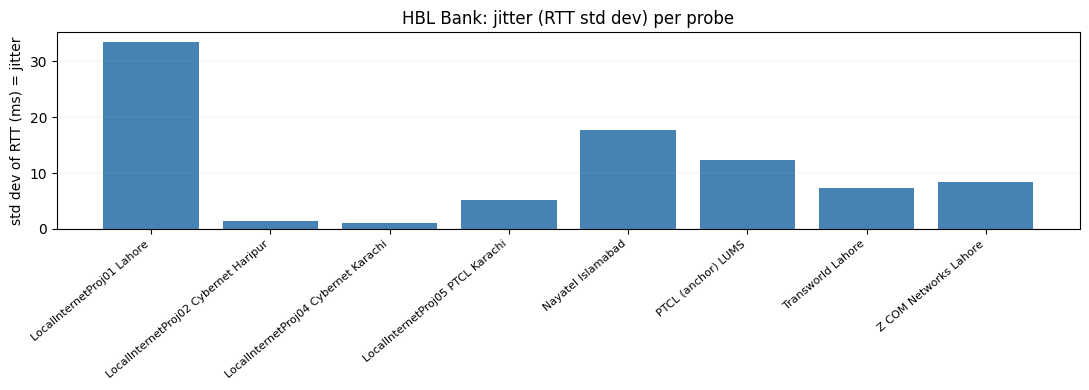

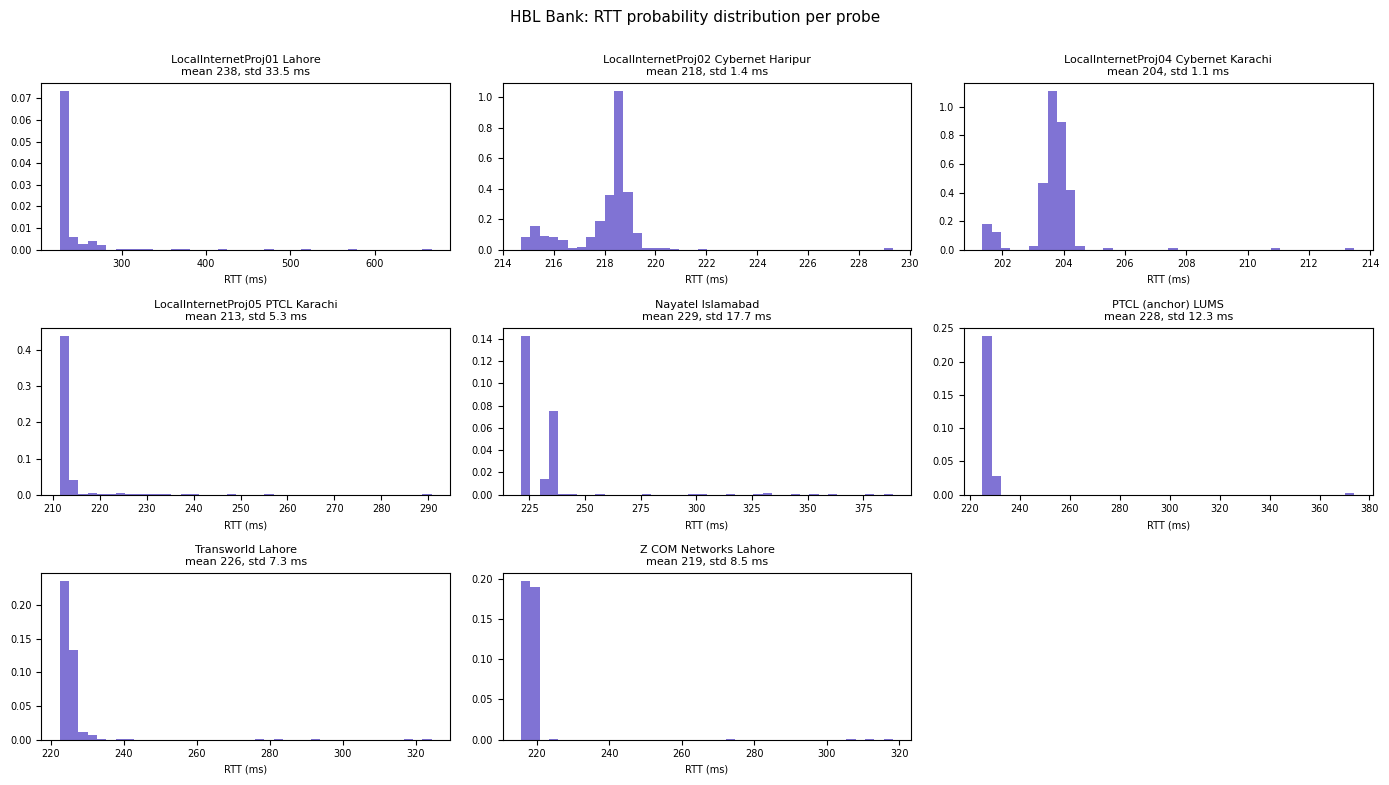

In [44]:
def dist_and_jitter(site):
    g = pg[(pg['target_label'] == site)].dropna(subset=['rtt_avg'])
    probes = [p for p in PROBES if p in set(g['probe_city'])]
    # --- jitter (std dev) per probe ---
    jit = g.groupby('probe_city')['rtt_avg'].std().reindex(probes)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(range(len(jit)), jit.values, color='steelblue')
    ax.set_xticks(range(len(jit))); ax.set_xticklabels(jit.index, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('std dev of RTT (ms) = jitter')
    ax.set_title(f'{site}: jitter (RTT std dev) per probe'); ax.grid(True, axis='y', lw=0.3, alpha=0.4)
    plt.tight_layout(); plt.show()
    # --- distribution per probe (small multiples) ---
    ncol = 3; nrow = (len(probes) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.6 * nrow))
    for ax, p in zip(axes.flat, probes):
        v = g[g['probe_city'] == p]['rtt_avg']
        ax.hist(v, bins=40, density=True, color='slateblue', alpha=0.85)
        ax.set_title(f'{p}\nmean {v.mean():.0f}, std {v.std():.1f} ms', fontsize=8)
        ax.set_xlabel('RTT (ms)', fontsize=7); ax.tick_params(labelsize=7)
    for ax in axes.flat[len(probes):]: ax.axis('off')
    fig.suptitle(f'{site}: RTT probability distribution per probe', y=1.0, fontsize=11)
    plt.tight_layout(); plt.show()

dist_and_jitter('HBL Bank')

## 10. Tables: real path changes and probe ASN

Real changes are NADRA/MCB serving-city flips (`distinct_metros > 1`). The PTCL
anchor's big `path_changes` numbers are last-hop flicker, not reroutes. The ASN table
confirms every probe stayed on its registered network all run.

In [45]:
rows = []
for (site, probe), g in df.sort_values('t').groupby(['target_label', 'probe_city']):
    p = g['asns_in_path'].dropna()
    ch = int((p.values[1:] != p.values[:-1]).sum()) if len(p) > 1 else 0
    metros = g['dest_location'].dropna().nunique()
    if ch > 0 or metros > 1:
        rows.append({'site': site, 'probe': probe, 'path_changes': ch, 'distinct_metros': metros})
pc = pd.DataFrame(rows).sort_values(['distinct_metros', 'path_changes'], ascending=False).reset_index(drop=True)
print('Top movers (real flips have distinct_metros > 1):'); display(pc.head(12))

if 'probe_asn_reg' in df.columns:
    a = [{'probe': p, 'measured_asn': sorted(g['probe_asn'].dropna().unique()),
          'registered_asn': sorted(g['probe_asn_reg'].dropna().unique()),
          'stable': sorted(g['probe_asn'].dropna().unique()) == sorted(g['probe_asn_reg'].dropna().unique())}
         for p, g in df.groupby('probe_city')]
    print('\nDynamic egress ASN (measured vs registered):'); display(pd.DataFrame(a))

Top movers (real flips have distinct_metros > 1):


,site,probe,path_changes,distinct_metros
0,NADRA,LocalInternetProj02 Cybernet Haripur,7,6
1,NADRA,LocalInternetProj05 PTCL Karachi,24,3
2,NADRA,LocalInternetProj04 Cybernet Karachi,7,3
3,Dawn,LocalInternetProj04 Cybernet Karachi,4,2
4,MCB Bank,Z COM Networks Lahore,3,2
5,Geo TV,LocalInternetProj04 Cybernet Karachi,2,2
6,MCB Bank,Nayatel Islamabad,2,2
7,MCB Bank,LocalInternetProj01 Lahore,1,2
8,Dawn,LocalInternetProj02 Cybernet Haripur,0,2
9,Geo TV,LocalInternetProj02 Cybernet Haripur,0,2



Dynamic egress ASN (measured vs registered):


,probe,measured_asn,registered_asn,stable
0,LocalInternetProj01 Lahore,[136174],[136174],True
1,LocalInternetProj02 Cybernet Haripur,[9541],[9541],True
2,LocalInternetProj04 Cybernet Karachi,[9541],[9541],True
3,LocalInternetProj05 PTCL Karachi,[17557],[17557],True
4,Nayatel Islamabad,[23674],[23674],True
5,PTCL (anchor) LUMS,[17557],[17557],True
6,Transworld Lahore,[38193],[38193],True
7,Z COM Networks Lahore,[152605],[152605],True
